In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [11]:
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('datasets/adult_cleaned.csv')
df.head()

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   fnlwgt          45222 non-null  int64 
 3   education       45222 non-null  object
 4   marital-status  45222 non-null  object
 5   occupation      45222 non-null  object
 6   relationship    45222 non-null  object
 7   race            45222 non-null  object
 8   sex             45222 non-null  object
 9   capital-gain    45222 non-null  int64 
 10  capital-loss    45222 non-null  int64 
 11  hours-per-week  45222 non-null  int64 
 12  native-country  45222 non-null  object
 13  target          45222 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 4.8+ MB


In [14]:
df.describe()

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,target
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,1101.430344,88.595418,40.938017,0.166025
std,13.217870,1.056392e+05,7506.430084,404.956092,12.007508,0.372108
min,17.000000,1.349200e+04,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.173882e+05,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783160e+05,0.000000,0.000000,40.000000,0.000000
75%,47.000000,2.379260e+05,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,99999.000000,4356.000000,99.000000,1.000000


In [15]:
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,45222,45222,45222,45222,45222,45222,45222,45222
unique,7,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
freq,33307,14783,21055,6020,18666,38903,30527,41292


In [16]:
numeric_features = [
    'age', 'fnlwgt', 'capital-gain',
    'capital-loss', 'hours-per-week'
]
categorical_features = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country', 'target'
]

In [17]:
corr_matrix = df[numeric_features].corr()
corr_matrix

,age,fnlwgt,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.075792,0.079683,0.059351,0.101992
fnlwgt,-0.075792,1.000000,-0.004110,-0.004349,-0.018679
capital-gain,0.079683,-0.004110,1.000000,-0.032102,0.083880
capital-loss,0.059351,-0.004349,-0.032102,1.000000,0.054195
hours-per-week,0.101992,-0.018679,0.083880,0.054195,1.000000


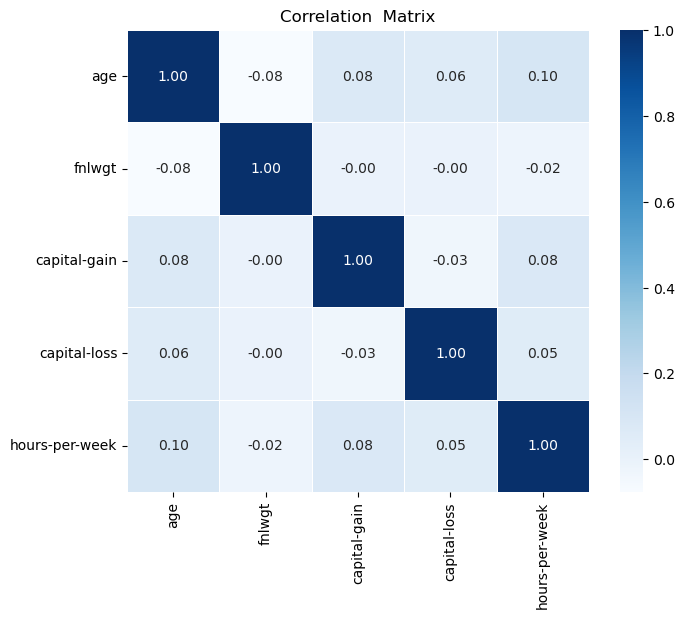

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap='Blues', fmt='.2f',
    linewidths=0.5, square=True
)
plt.title('Correlation  Matrix')
plt.show()

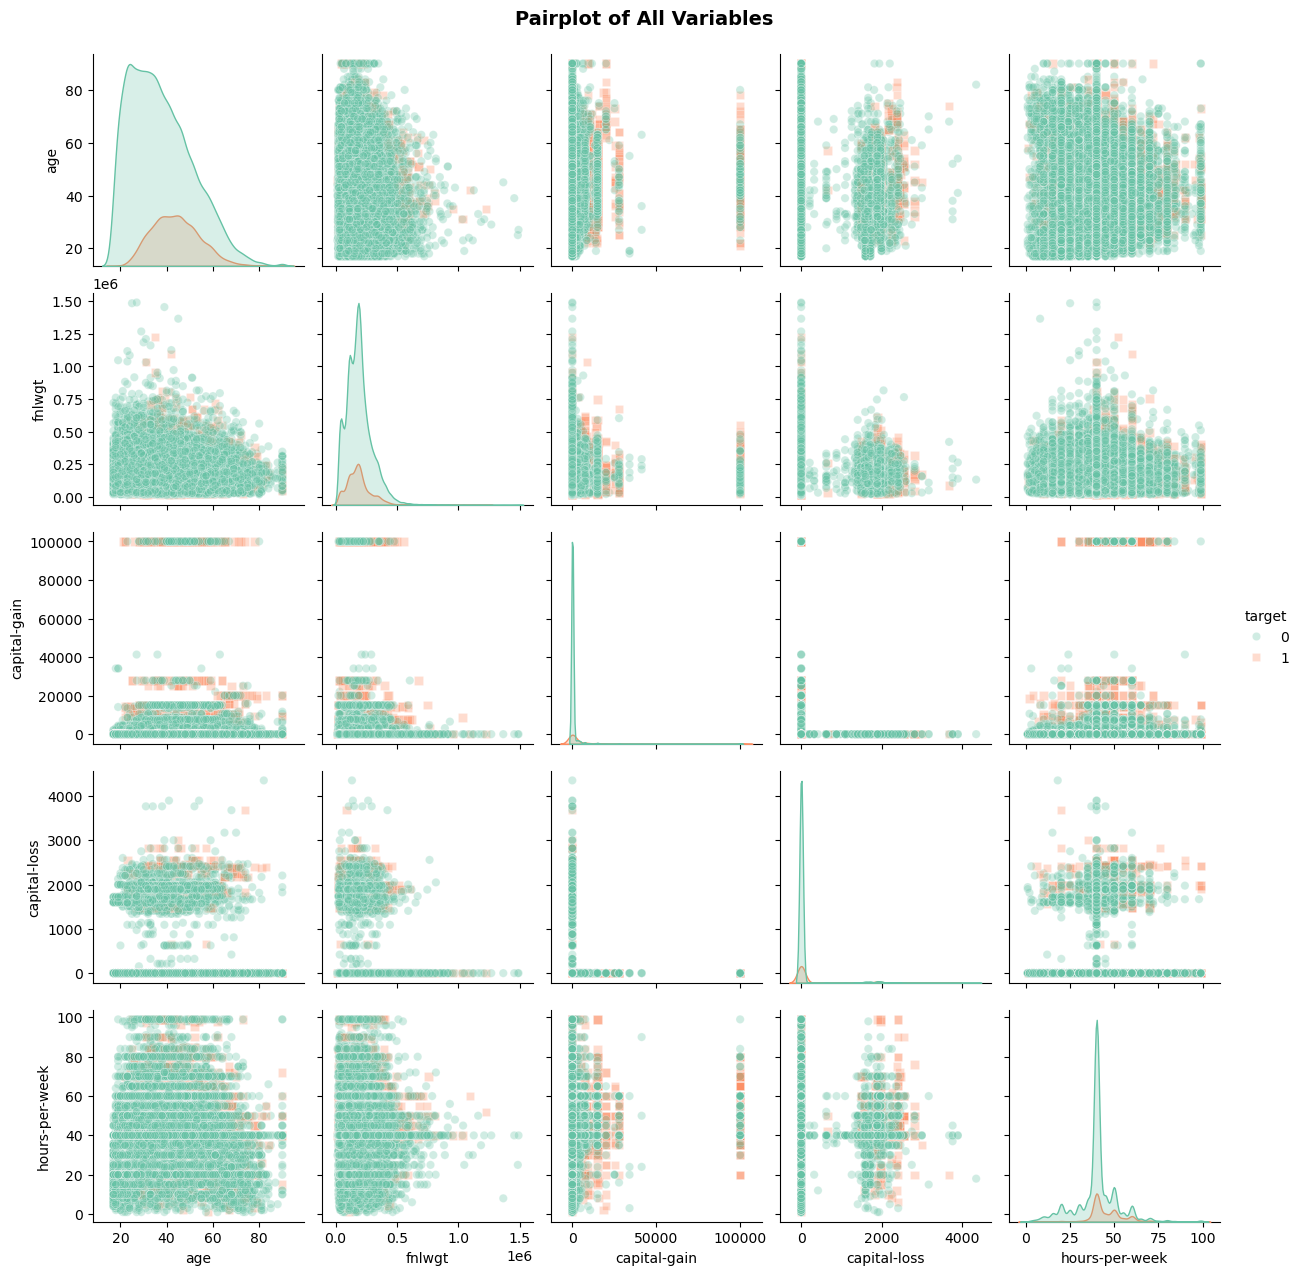

In [19]:
pairplot_variable = numeric_features + ['target']
sns.pairplot(
    df[pairplot_variable],
    hue='target',
    markers=['o', 's'],
    palette='Set2',
    diag_kind='kde',
    height=2.5,
    plot_kws={'alpha': 0.3},
    diag_kws={'fill': True}
)
plt.suptitle(
    'Pairplot of All Variables', y=1.02, fontsize=14, fontweight='bold'
)
plt.show()

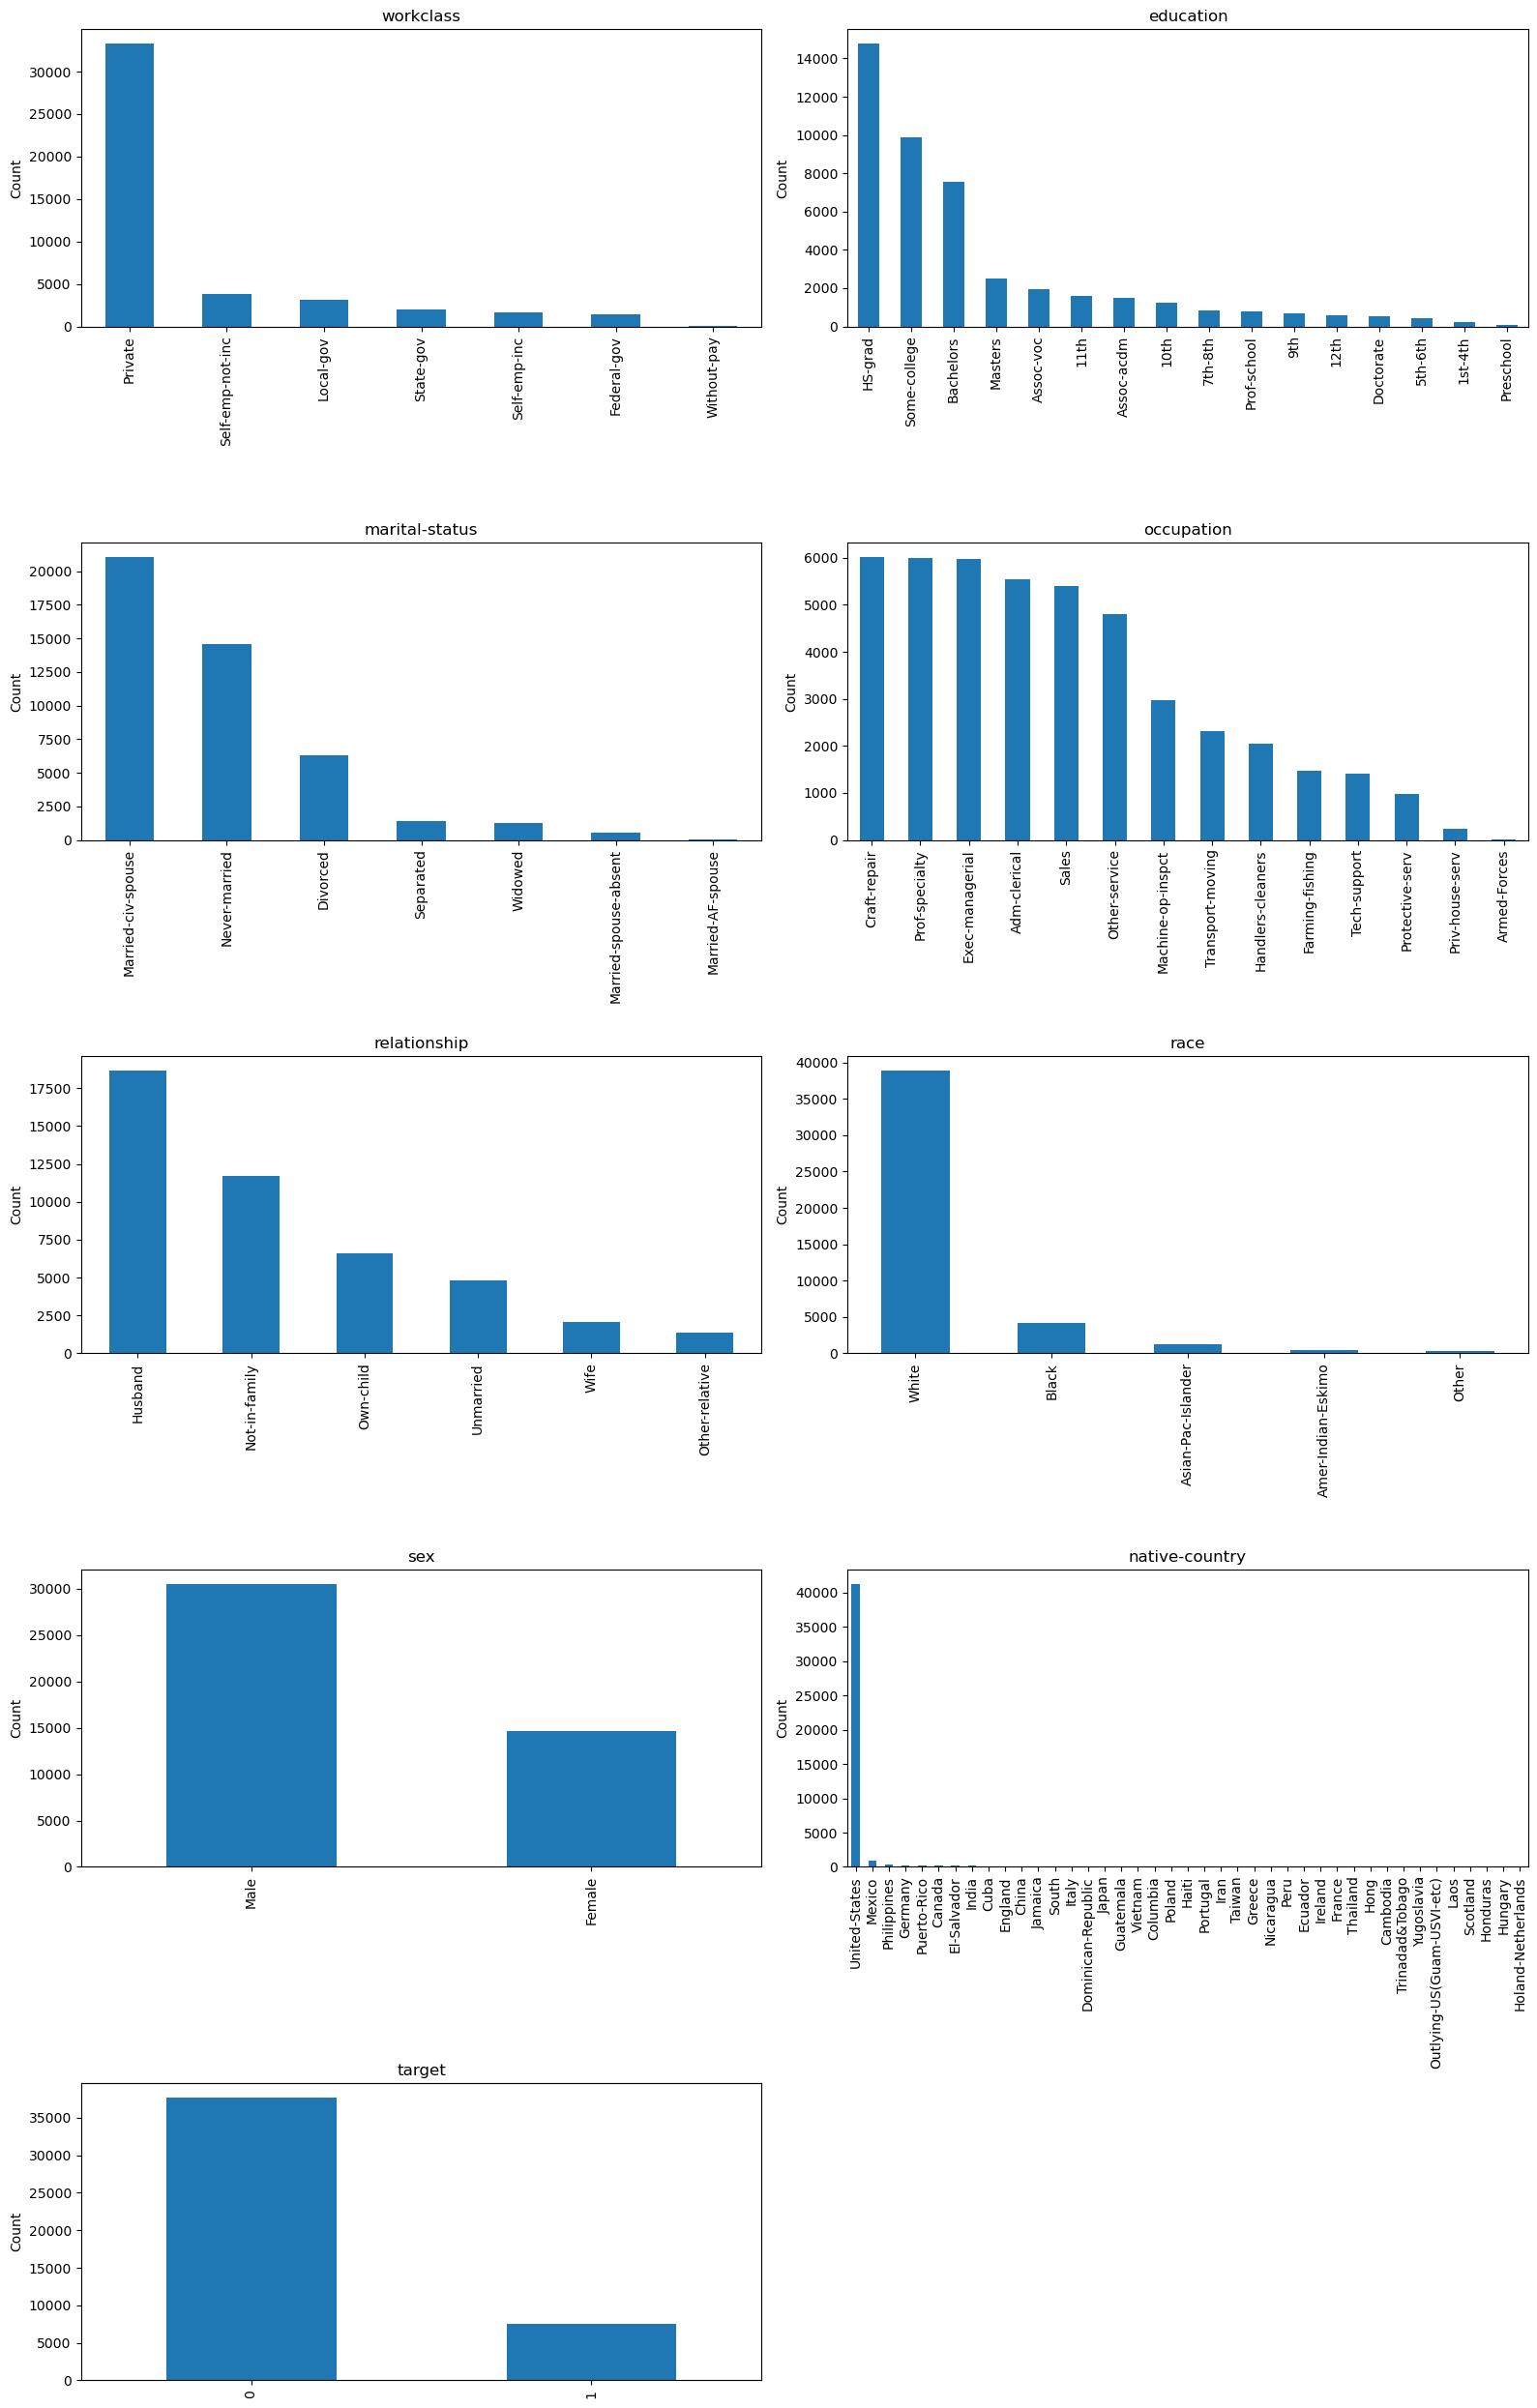

In [20]:
ncols = 2
nrows = (len(categorical_features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=90)

for i in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


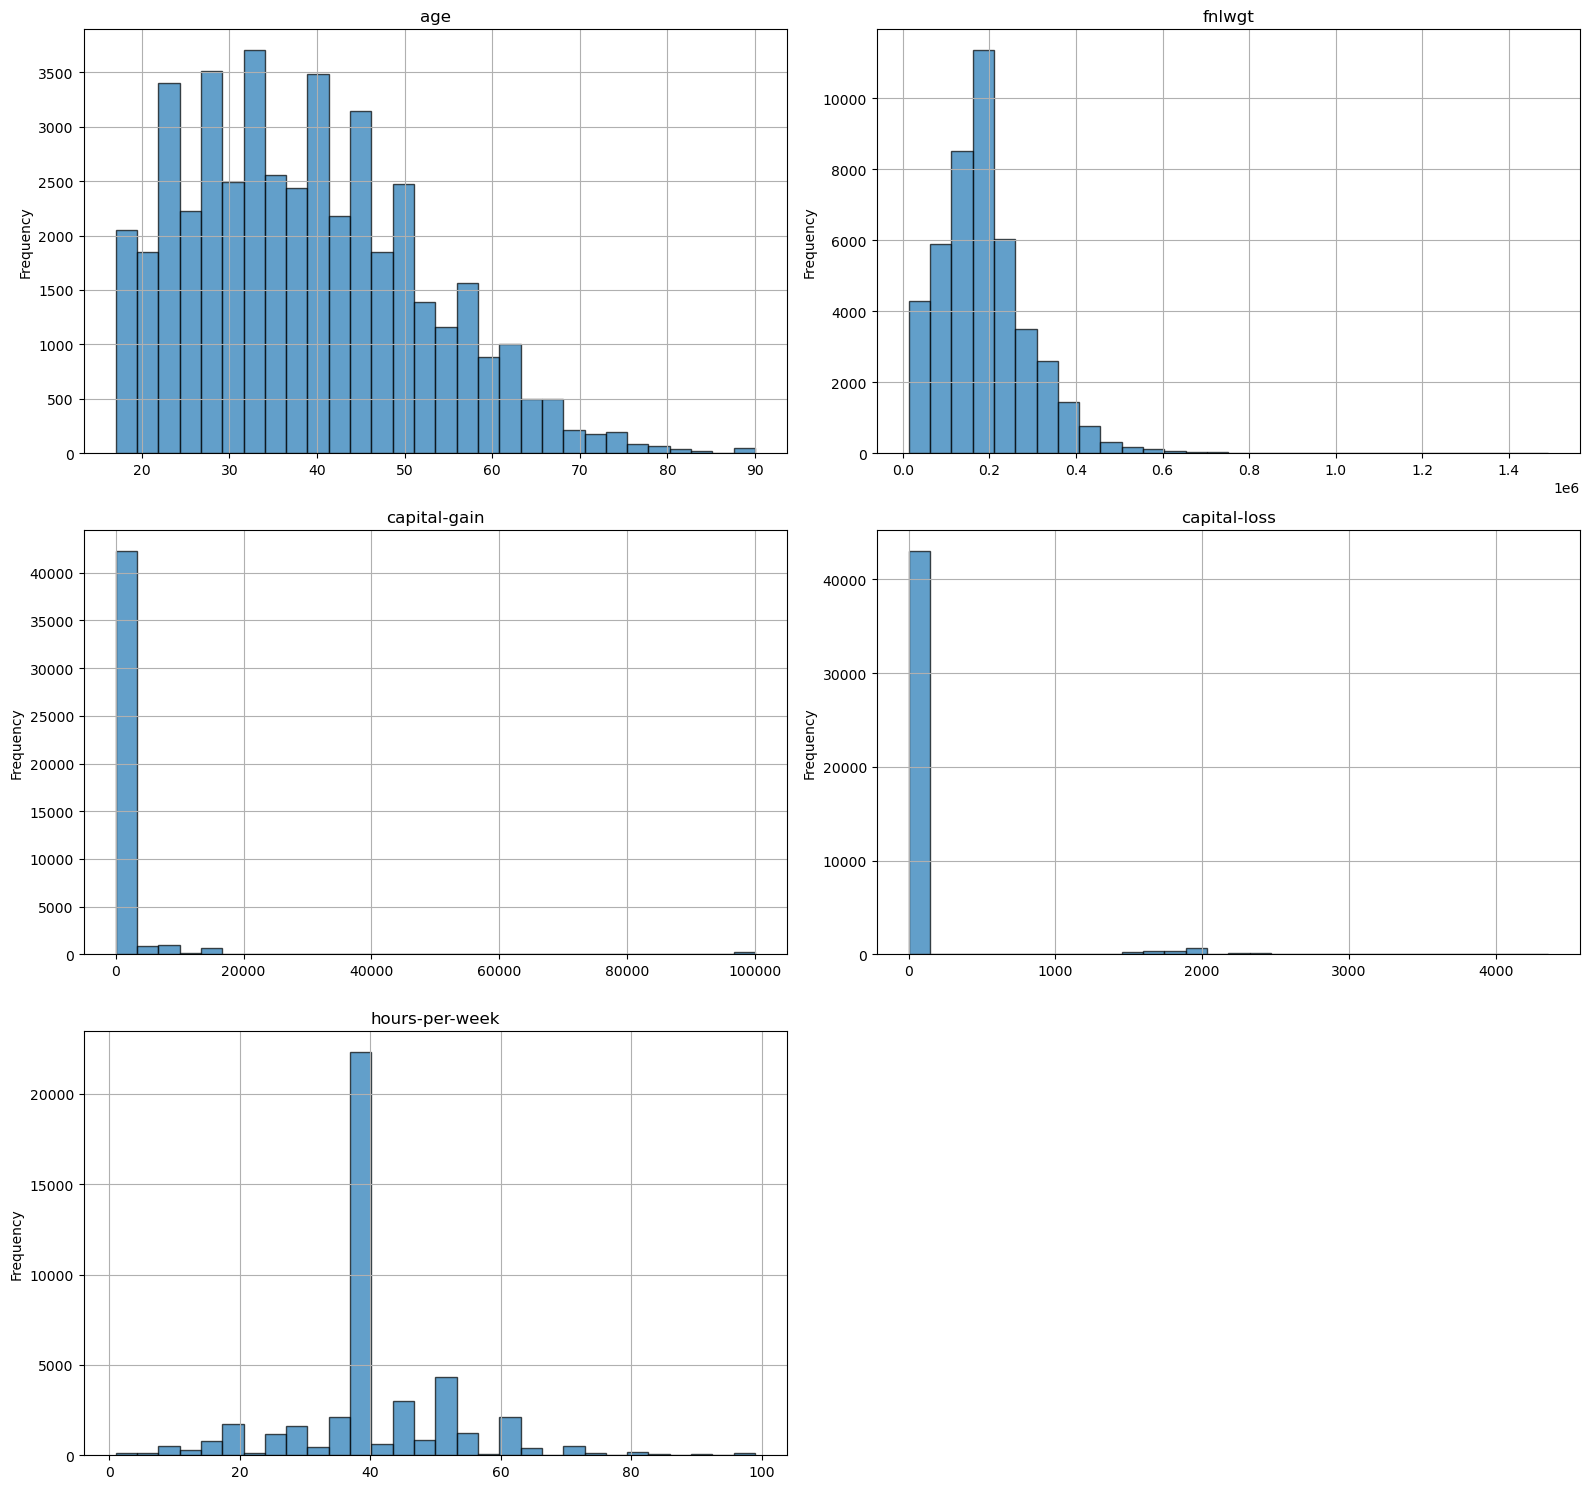

In [21]:
ncols = 2
nrows = (len(numeric_features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df[col].hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [22]:
categorical_features.remove('target')

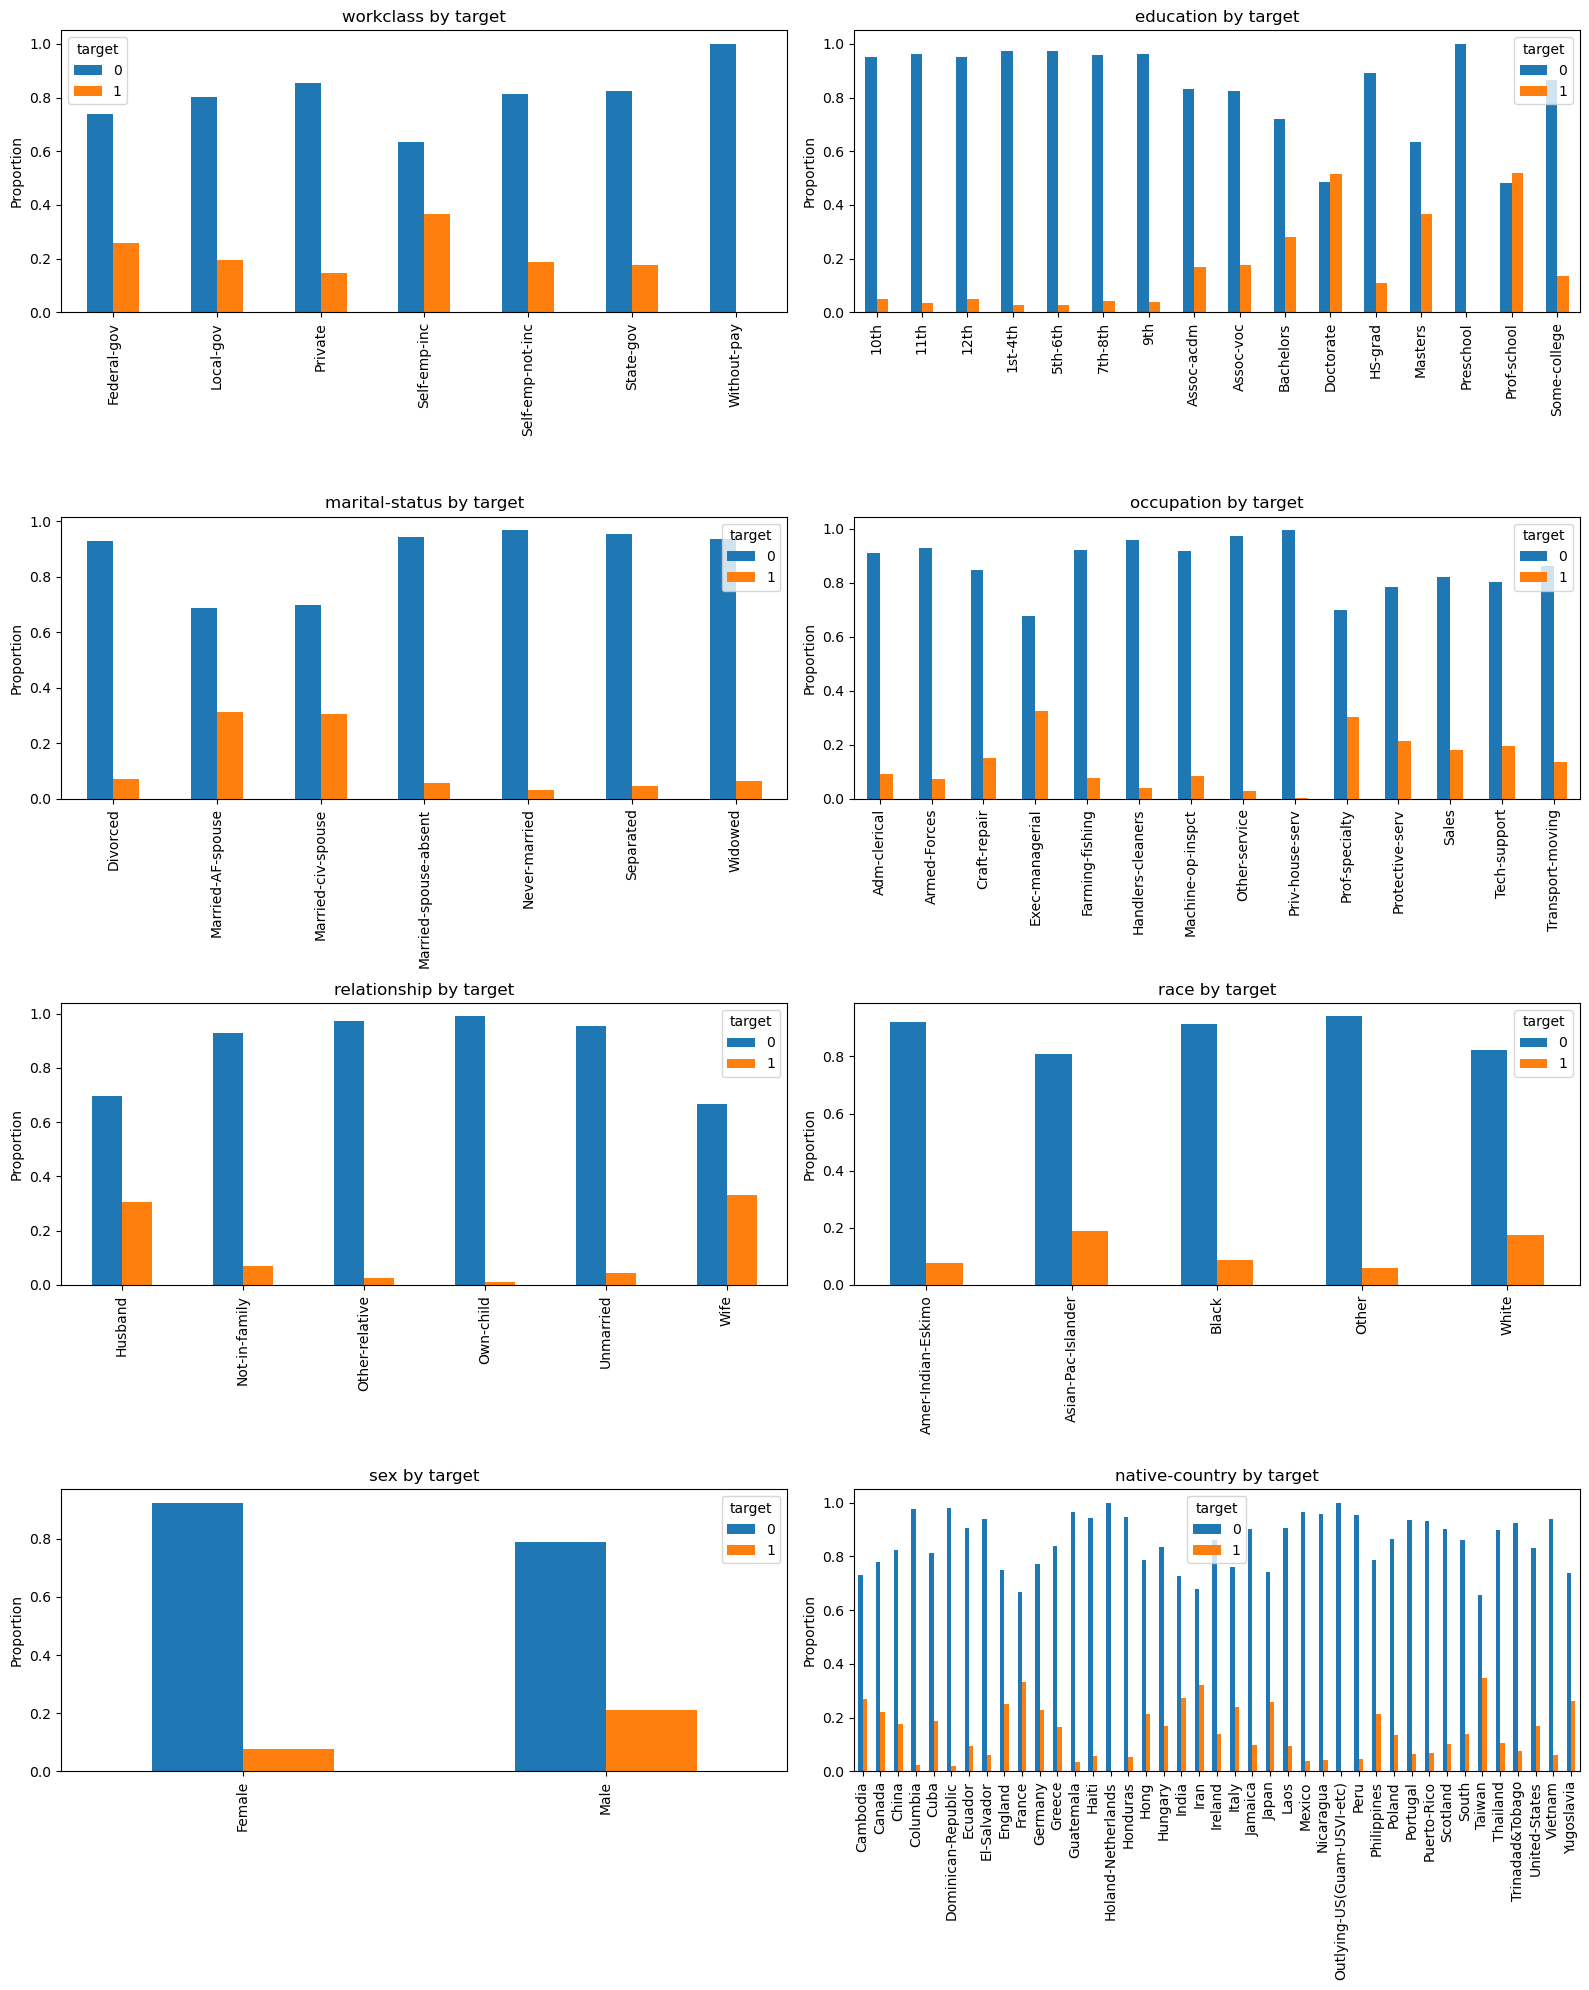

In [23]:
ncols = 2
nrows = (len(categorical_features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    pd.crosstab(
        df[col], df['target'], normalize='index'
    ).plot(
        kind='bar', ax=axes[i], stacked=False
    )
    axes[i].set_title(f'{col} by target')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend(title='target')

for i in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

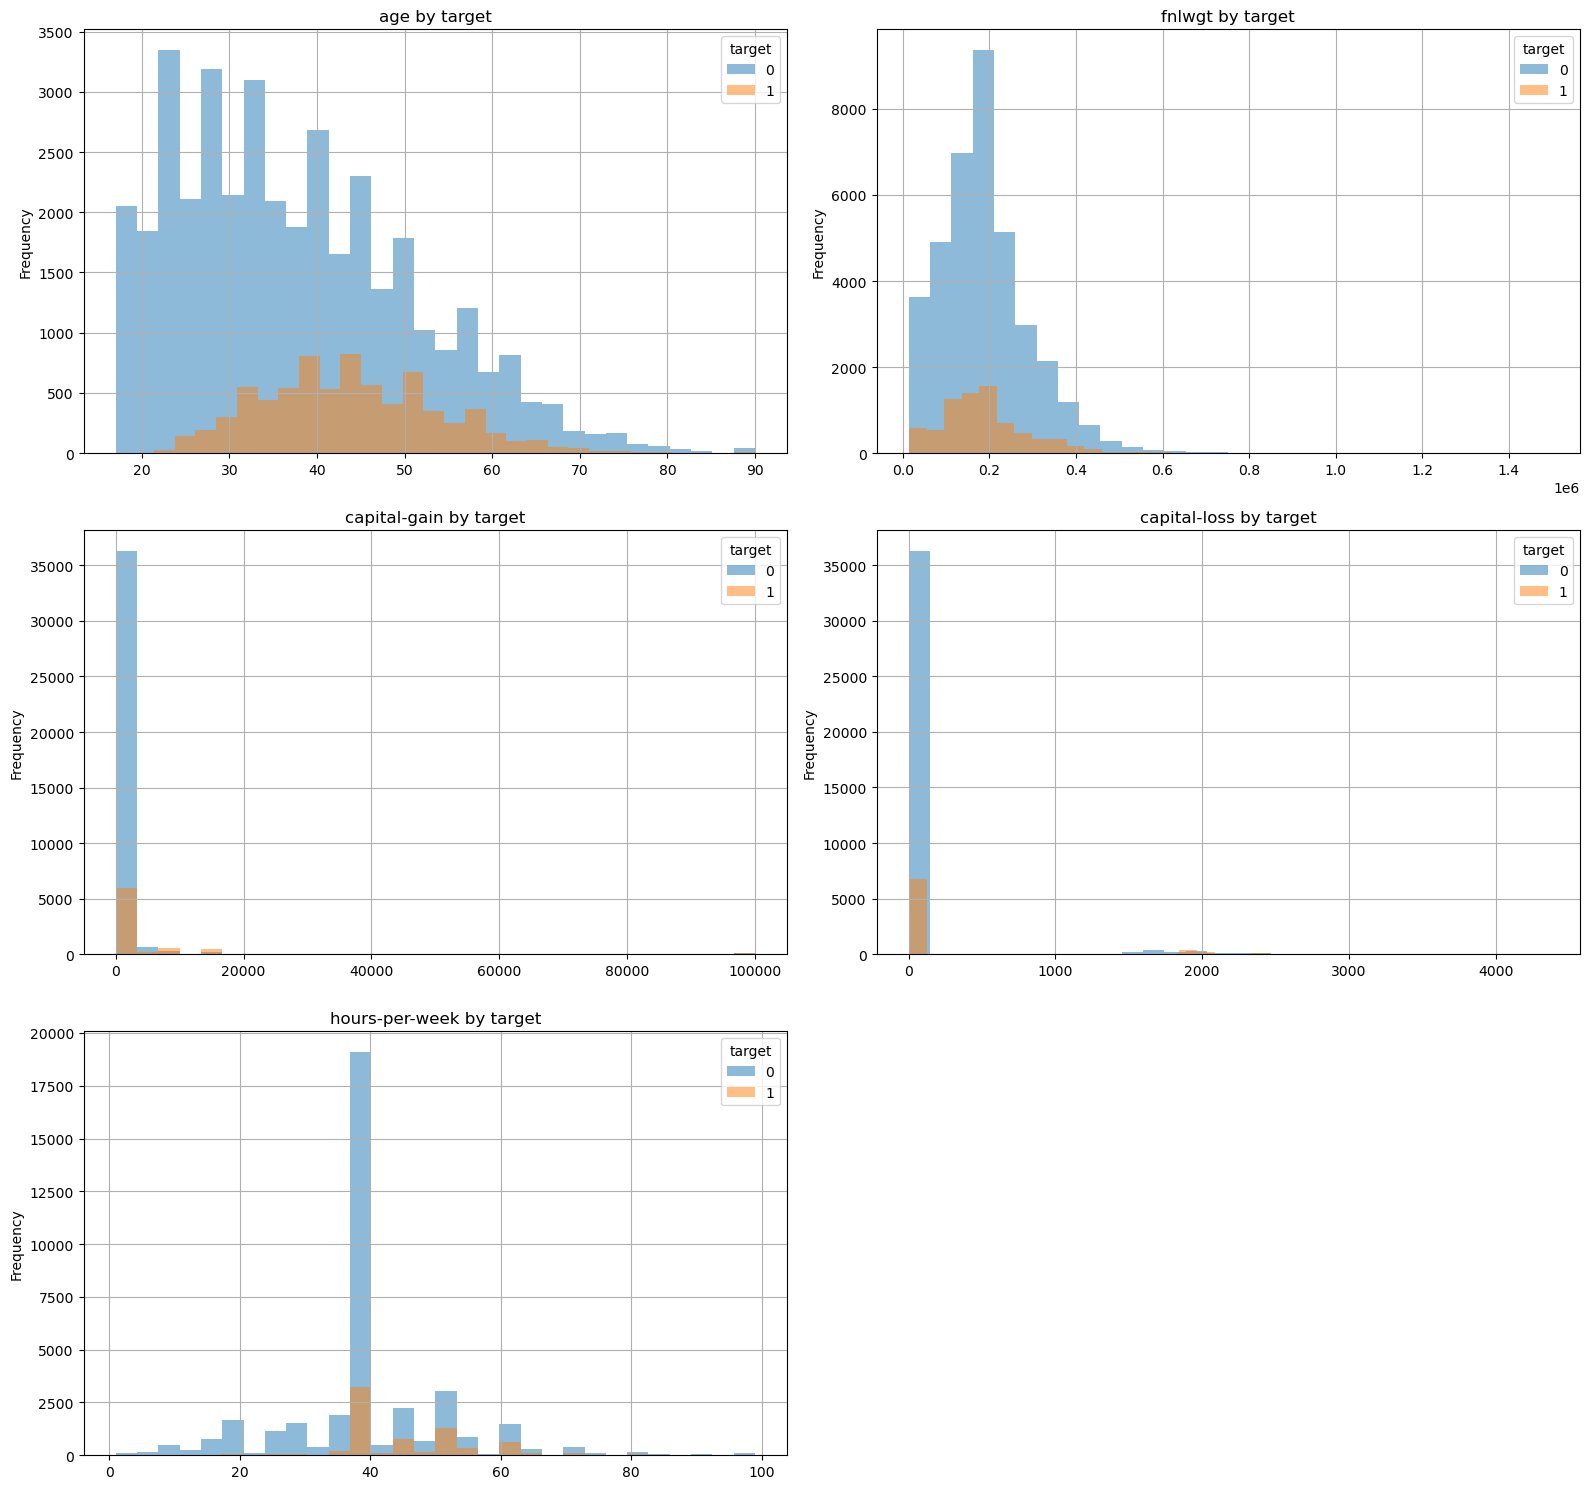

In [24]:
ncols = 2
nrows = (len(numeric_features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    for category in df['target'].unique():
        df[df['target'] == category][col].hist(
            bins=30, alpha=0.5, label=category, ax=axes[i]
        )
    axes[i].set_title(f'{col} by target')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='target')

for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

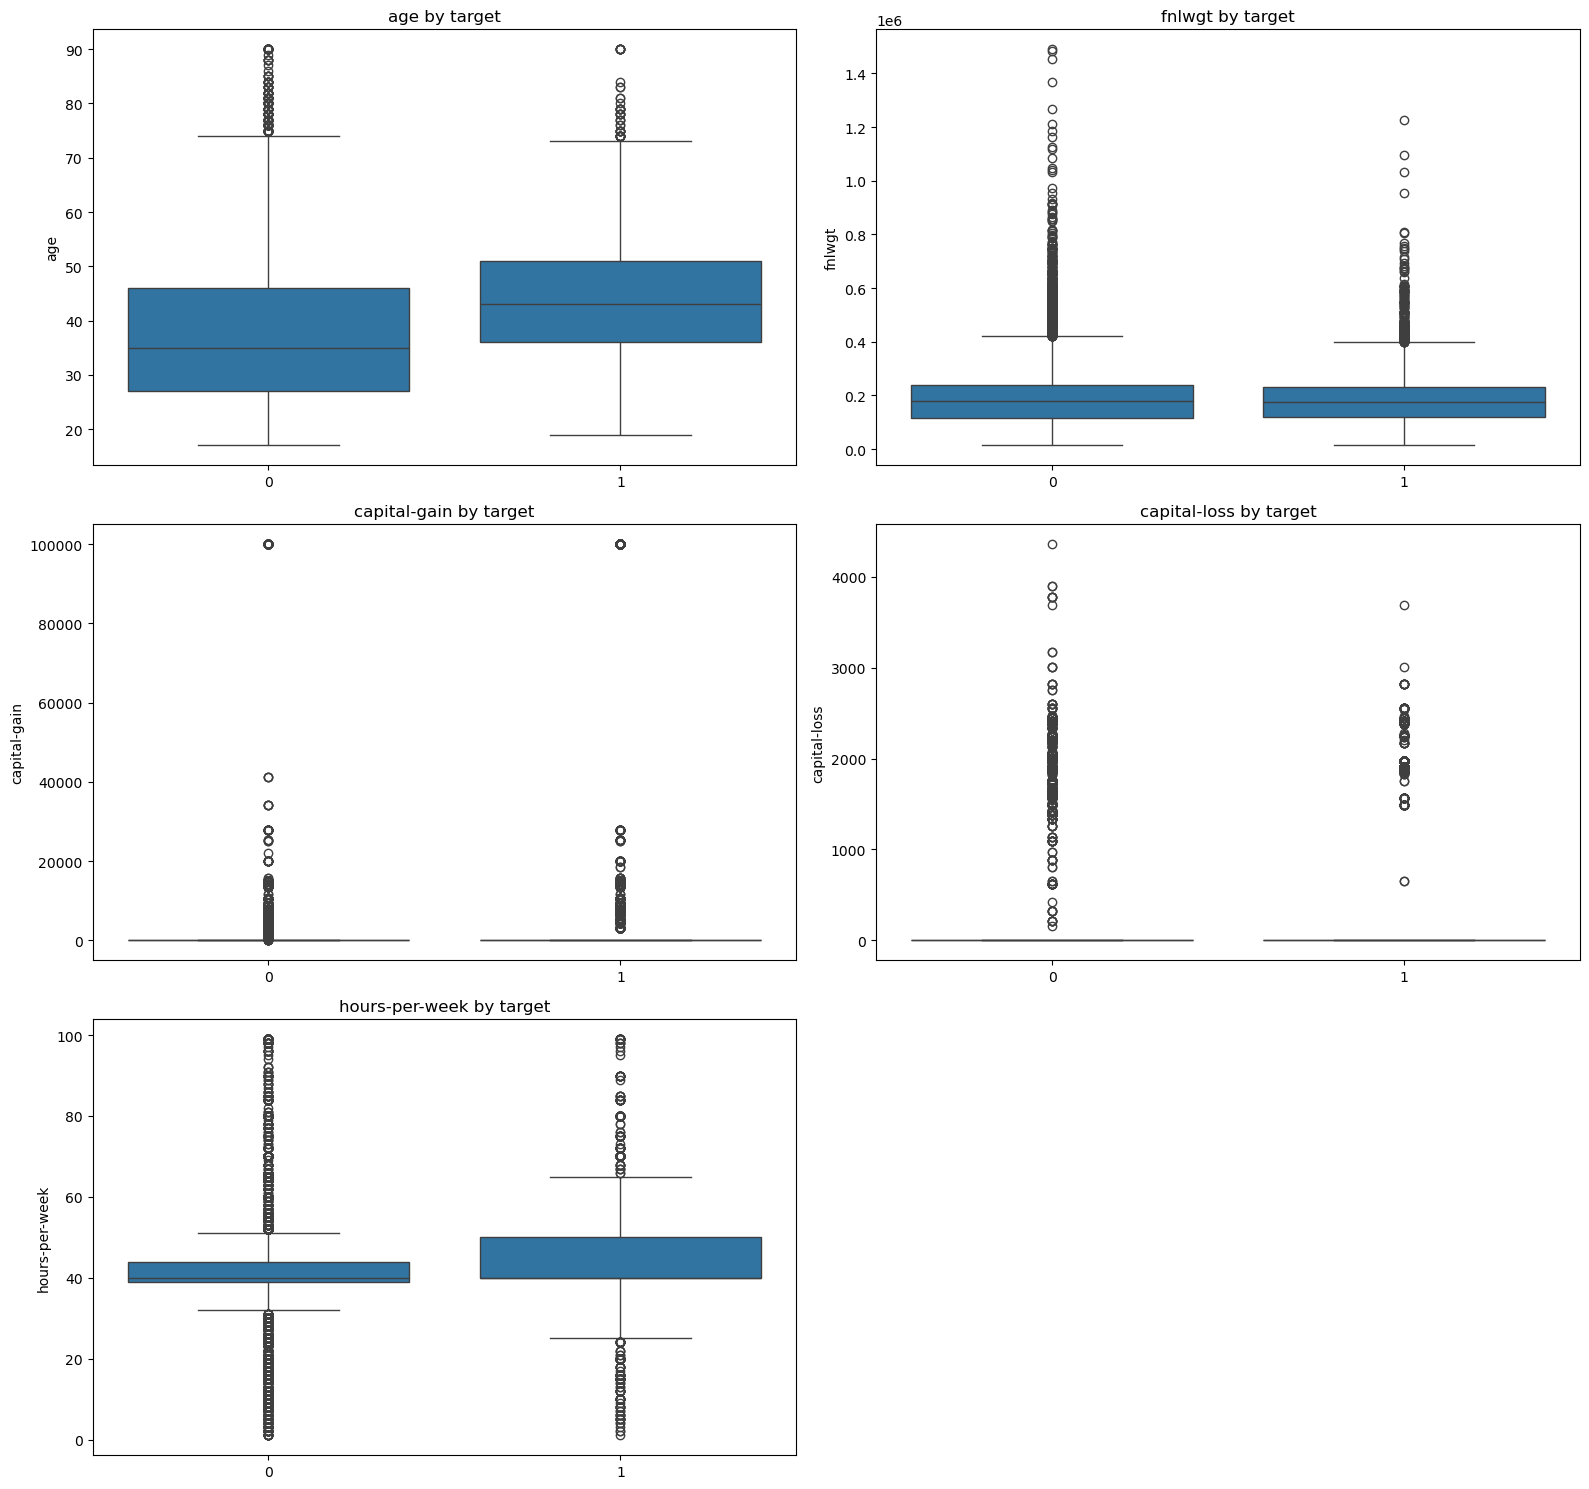

In [25]:
ncols = 2
nrows = (len(numeric_features) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by target')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()